# Retina Display PPI Analysis

## What is a "Retina" display?

Apple's "Retina" display is defined as a display where individual pixels cannot be 
distinguished by the human eye at a typical viewing distance. This is based on the 
angular resolution limit of the human eye, which is approximately **1 arcminute** 
(1/60th of a degree) at optimal conditions.

## Formula

$$\text{PPI threshold} = \frac{1}{\text{viewing distance (cm)} \times \text{angular resolution in radians}} \times \frac{1}{2.54}$$

Or approximately: $$\text{PPI threshold} \approx \frac{8738.74}{\text{viewing distance (cm)}}$$


In [1]:
import math

# Angular resolution in radians (1 arcminute = 1/60 degrees)
# Approximately 0.000290888 radians
ARCMINUTE_TO_RADIANS = math.pi / (60 * 180)
INCHES_TO_CM = 2.54


def calculate_ppi_threshold(viewing_distance_cm):

    # Convert cm to inches for calculation (PPI is pixels per inch)
    viewing_distance_inches = viewing_distance_cm / INCHES_TO_CM

    # Using the small angle approximation
    ppi_threshold = 1 / (viewing_distance_inches * ARCMINUTE_TO_RADIANS)

    return ppi_threshold

## Ergonomic Guidelines on Optimal Viewing Distances for Desktop Setups

Recommended viewing distances for desktop computer setups based on ergonomic standards:

- [**ISO 9241-5** (Ergonomics of Human-System Interaction):](https://www.iso.org/standard/86222.html) Recommends viewing distance of 50-100 cm for desktop displays
- [**OSHA** (Occupational Safety and Health Administration):](https://www.osha.gov/etools/computer-workstations/components/monitors/) Suggests monitor distance of 20-40 inches (50-100 cm) with top of screen at or slightly below eye level
- [**HSE** (Health and Safety Executive, UK):](https://www.hse.gov.uk/pubns/books/l26.htm) Recommends viewing distance of 50-60 cm for computer workstations


## Create and Display the Plot


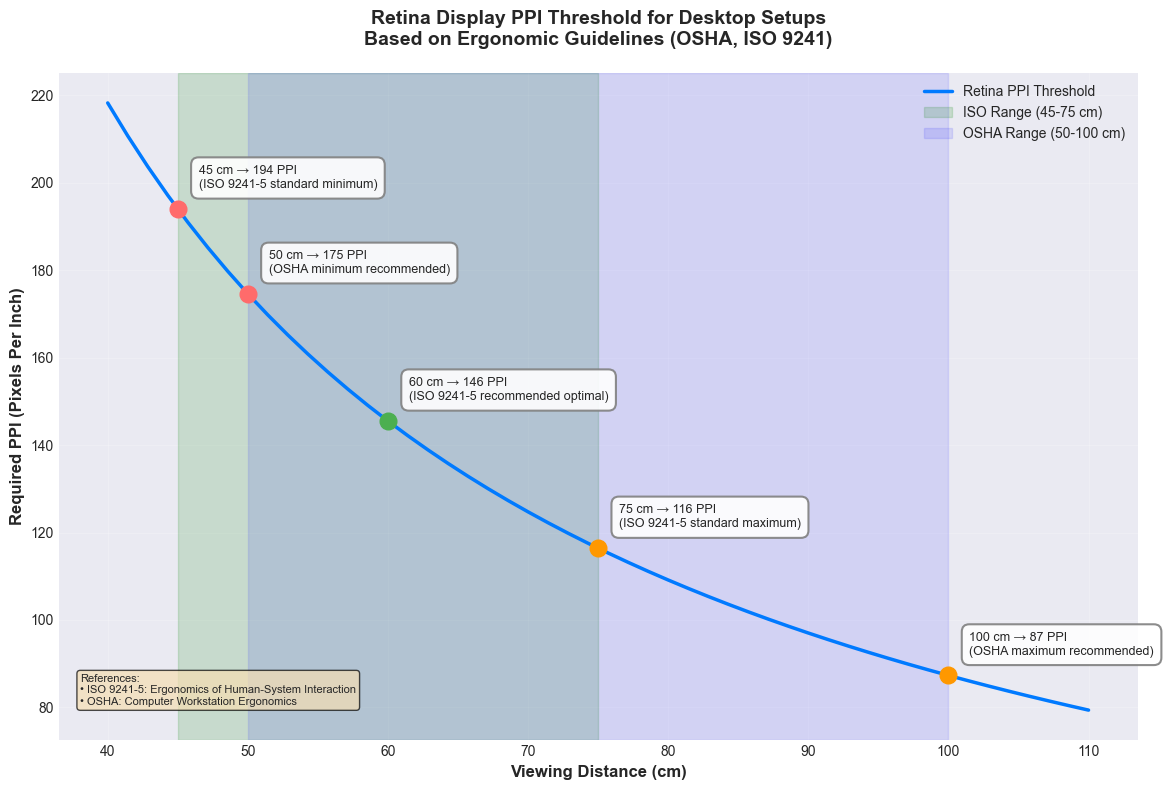

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up plotting style (try seaborn, fallback to default)
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')
        print("Using default matplotlib style")

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

viewing_distances_cm = np.linspace(40, 110)  # Smooth curve from 40 to 110 cm
ppi_thresholds = [calculate_ppi_threshold(d) for d in viewing_distances_cm]
ax.plot(viewing_distances_cm, ppi_thresholds, linewidth=2.5, color='#007AFF', 
        label='Retina PPI Threshold')

# Ergonomic guidelines from credible sources
ergonomic_guidelines = {
    'ISO Minimum: 45 cm': (45, calculate_ppi_threshold(45), 'ISO 9241-5 standard minimum'),
    'OSHA Minimum: 50 cm': (50, calculate_ppi_threshold(50), 'OSHA minimum recommended'),
    'ISO Optimal: 60 cm': (60, calculate_ppi_threshold(60), 'ISO 9241-5 recommended optimal'),
    'ISO Maximum: 75 cm': (75, calculate_ppi_threshold(75), 'ISO 9241-5 standard maximum'),
    'OSHA Maximum: 100 cm': (100, calculate_ppi_threshold(100), 'OSHA maximum recommended'),
}

# Color coding for different guideline ranges
for guideline_name, (distance, ppi, description) in ergonomic_guidelines.items():
    ax.plot(distance, ppi, 'o', markersize=12, zorder=5, 
            color='#FF6B6B' if 'Min' in guideline_name else 
                  '#4CAF50' if 'Optimal' in guideline_name else '#FF9800')
    ax.annotate(f'{distance} cm → {ppi:.0f} PPI\n({description})', 
                xy=(distance, ppi), 
                xytext=(15, 15), 
                textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='white', 
                         edgecolor='gray', alpha=0.9, linewidth=1.5),
                fontsize=9, ha='left')

# Add shaded regions for recommended ranges
ax.axvspan(45, 75, alpha=0.15, color='green', label='ISO Range (45-75 cm)')
ax.axvspan(50, 100, alpha=0.1, color='blue', label='OSHA Range (50-100 cm)')

ax.grid(True, alpha=0.2)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Add text annotation with sources
source_text = ('References:\n'
               '• ISO 9241-5: Ergonomics of Human-System Interaction\n'
               '• OSHA: Computer Workstation Ergonomics')
ax.text(0.02, 0.1, source_text, transform=ax.transAxes, 
        fontsize=8, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.set_xlabel('Viewing Distance (cm)', fontsize=12, fontweight='bold')
ax.set_ylabel('Required PPI (Pixels Per Inch)', fontsize=12, fontweight='bold')
ax.set_title('Retina Display PPI Threshold for Desktop Setups\n'
             'Based on Ergonomic Guidelines (OSHA, ISO 9241)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

# # Save the plot before displaying
# output_path = Path("retina_ppi_threshold.png")
# plt.savefig(output_path, dpi=300, bbox_inches='tight')
# print(f"Plot saved to: {output_path.absolute()}")

plt.show()
